In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/cs-training.csv")

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.shape 

(150000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
df.describe() 

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [8]:
df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [10]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
}).sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000
Unnamed: 0,0,0.000000
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Unnamed: 0                              150000
SeriousDlqin2yrs                             2
RevolvingUtilizationOfUnsecuredLines    125728
age                                         86
NumberOfTime30-59DaysPastDueNotWorse        16
DebtRatio                               114194
MonthlyIncome                            13594
NumberOfOpenCreditLinesAndLoans             58
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
dtype: int64

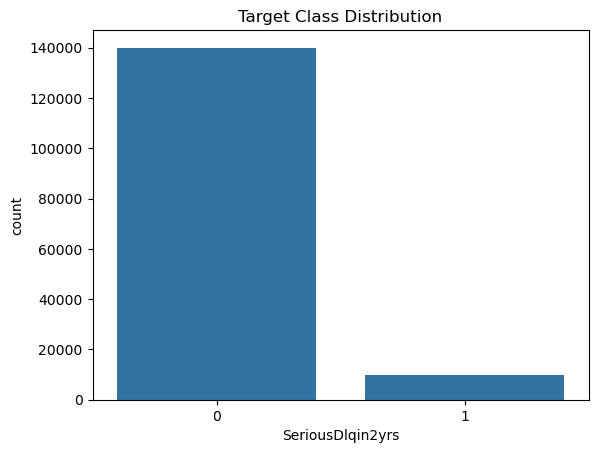

In [13]:
sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Target Class Distribution")
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

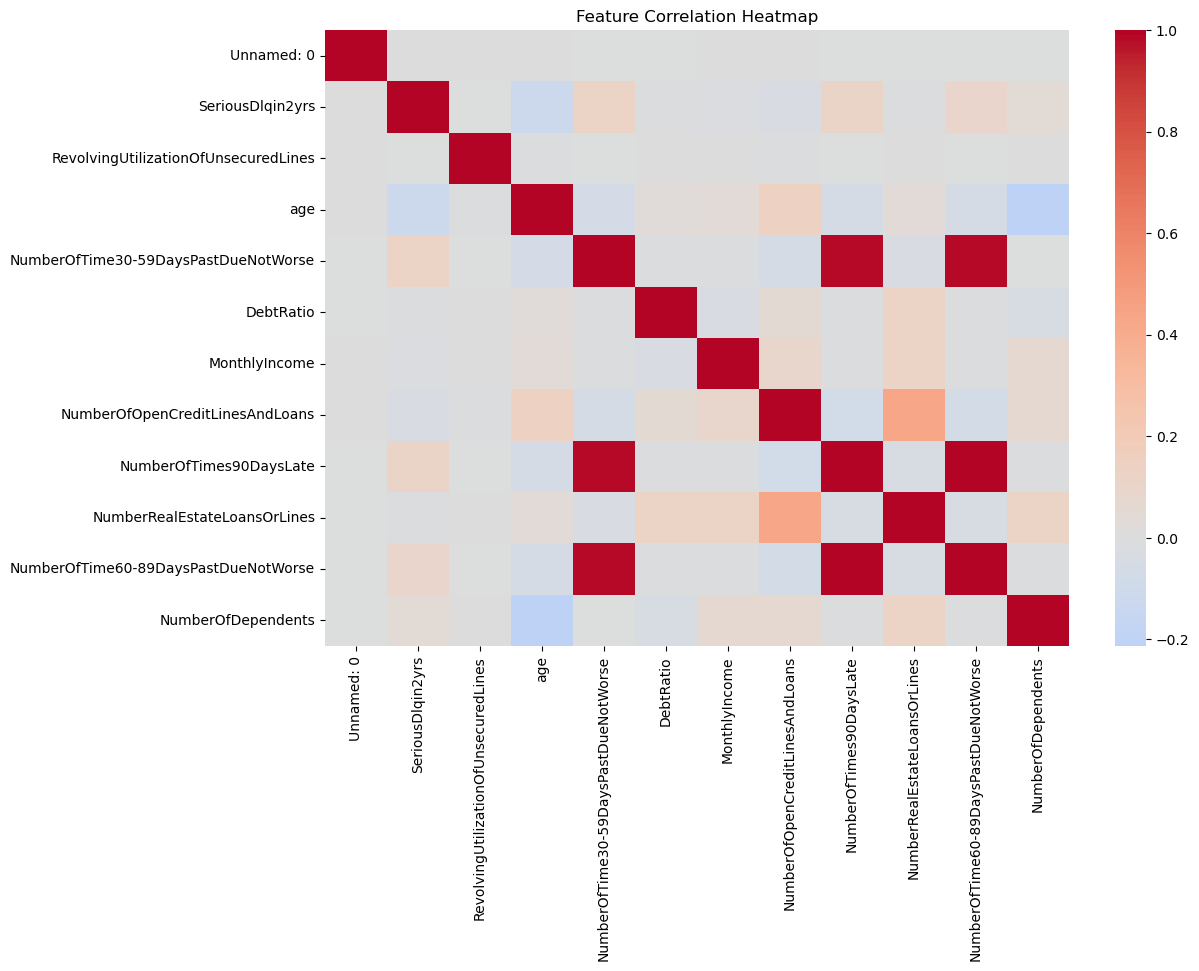

In [15]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.nunique().sort_values()

SeriousDlqin2yrs                             2
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
NumberOfTime30-59DaysPastDueNotWorse        16
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfOpenCreditLinesAndLoans             58
age                                         86
MonthlyIncome                            13594
DebtRatio                               114194
RevolvingUtilizationOfUnsecuredLines    125728
Unnamed: 0                              150000
dtype: int64

In [18]:
df.nunique().sort_values()

SeriousDlqin2yrs                             2
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
NumberOfTime30-59DaysPastDueNotWorse        16
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfOpenCreditLinesAndLoans             58
age                                         86
MonthlyIncome                            13594
DebtRatio                               114194
RevolvingUtilizationOfUnsecuredLines    125728
Unnamed: 0                              150000
dtype: int64

In [19]:
target_percentages = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

print(target_percentages)

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [20]:
default_rate = df["SeriousDlqin2yrs"].mean()

print(f"Default rate: {default_rate:.2%}")

Default rate: 6.68%


In [21]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000
Unnamed: 0,0,0.000000
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000


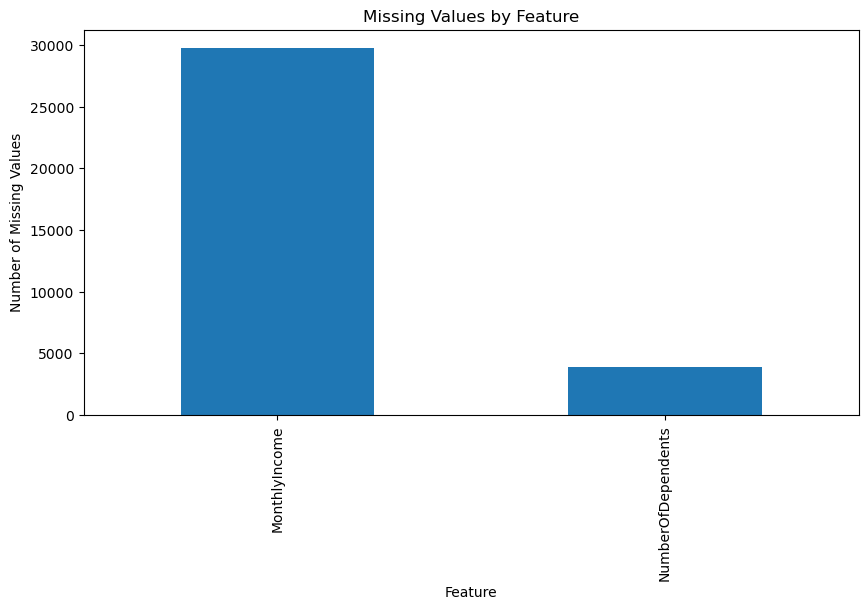

In [22]:
missing_data = df.isnull().sum()

missing_data = missing_data[missing_data > 0]

missing_data.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")

plt.show()

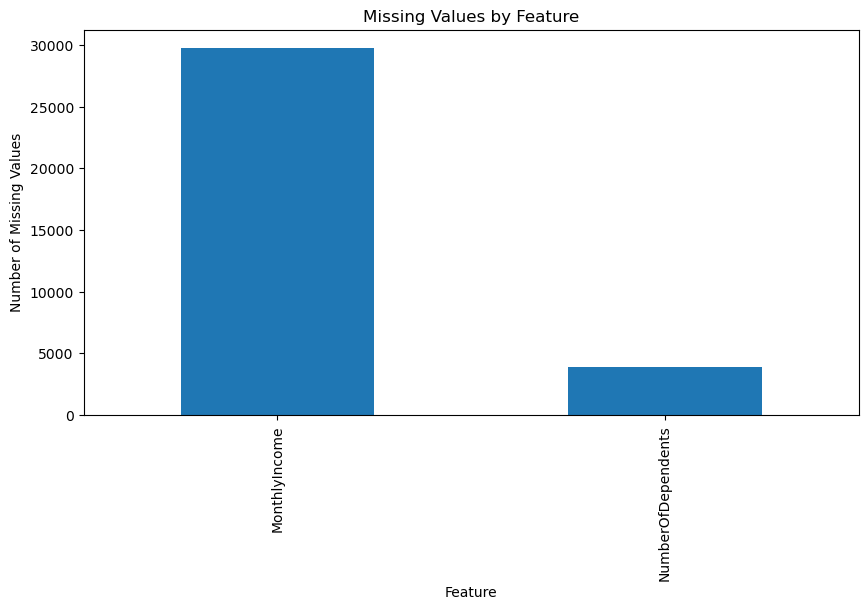

In [23]:
missing_data = df.isnull().sum()

missing_data = missing_data[missing_data > 0]

missing_data.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")

plt.show()

In [24]:
target = "SeriousDlqin2yrs"

features = df.drop(columns=[target])

print("Target:", target)
print("Number of features:", len(features.columns))
print("Target present in features:", target in features.columns)

Target: SeriousDlqin2yrs
Number of features: 11
Target present in features: False


In [25]:
print(df.columns.tolist())

['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [26]:
numeric_features = df.drop(columns=["SeriousDlqin2yrs"]).select_dtypes(
    include=np.number
)

target_correlations = numeric_features.corrwith(
    df["SeriousDlqin2yrs"]
).abs().sort_values(ascending=False)

target_correlations

NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
age                                     0.115386
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
NumberOfOpenCreditLinesAndLoans         0.029669
MonthlyIncome                           0.019746
DebtRatio                               0.007602
NumberRealEstateLoansOrLines            0.007038
Unnamed: 0                              0.002801
RevolvingUtilizationOfUnsecuredLines    0.001802
dtype: float64

In [27]:
suspicious = target_correlations[target_correlations > 0.8]

if len(suspicious) == 0:
    print("No extremely high correlations found.")
else:
    print("Potentially suspicious features:")
    print(suspicious)

No extremely high correlations found.


In [28]:
def check_no_target_leakage(df, target):
    
    # Check that target exists
    if target not in df.columns:
        raise ValueError("Target column not found.")
    
    # Create feature dataframe
    features = df.drop(columns=[target])
    
    # Check target is not inside features
    if target in features.columns:
        raise ValueError("Target leakage detected!")
    
    # Check for suspiciously high correlations
    numeric_features = features.select_dtypes(include=np.number)
    
    correlations = numeric_features.corrwith(
        df[target]
    ).abs()
    
    suspicious = correlations[correlations > 0.8]
    
    if len(suspicious) > 0:
        print("Warning: suspiciously high correlations found:")
        print(suspicious)
    else:
        print("No extremely high correlations found.")
    
    print("Direct target leakage check passed.")

In [29]:
check_no_target_leakage(df, "SeriousDlqin2yrs")

No extremely high correlations found.
Direct target leakage check passed.


In [30]:
print(df["SeriousDlqin2yrs"].unique())

[1 0]


In [31]:
print(df["SeriousDlqin2yrs"].isnull().sum())

0


In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [33]:
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Minimum age: 0
Maximum age: 109


In [34]:
print("Age <= 0:", (df["age"] <= 0).sum())

Age <= 0: 1


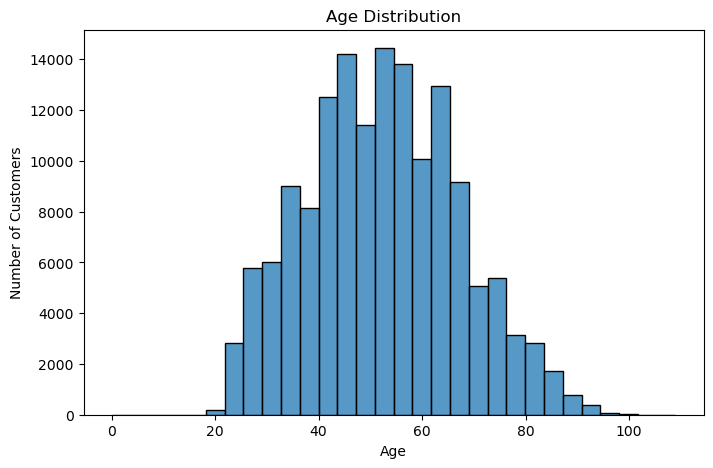

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

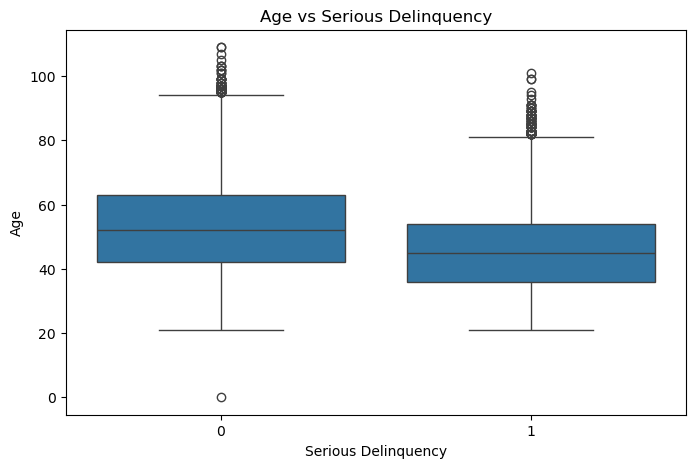

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="age"
)

plt.title("Age vs Serious Delinquency")
plt.xlabel("Serious Delinquency")
plt.ylabel("Age")

plt.show()

In [37]:
df.to_csv("../data/credit_risk_raw.csv", index=False)

In [38]:
print("===== DAY 1 SUMMARY =====")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print(f"Default rate: {df['SeriousDlqin2yrs'].mean():.2%}")

print(f"Duplicate rows: {df.duplicated().sum()}")

print(f"Missing values: {df.isnull().sum().sum()}")

print("\nTarget distribution:")
print(df["SeriousDlqin2yrs"].value_counts())

===== DAY 1 SUMMARY =====
Rows: 150000
Columns: 12
Default rate: 6.68%
Duplicate rows: 0
Missing values: 33655

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
